<a href="https://colab.research.google.com/github/priyanshubhatii07-ux/makesSENSE/blob/main/IoT_Air_Pollution_Monitoring_Design_a_Thon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Processing a More Comprehensive Sensor Dataset

To provide a more complete analysis for the IoT Air Pollution Monitor, we will now process a larger dataset containing various sensor readings, including `gas_mq135`, `co_mq7`, `temp`, `humidity`, `pm25`, `motion`, `distance`, and `light`. Since our AQI calculation primarily relies on PM2.5 and PM10, we will simulate PM10 values based on PM2.5 for this expanded dataset to apply the previously defined AQI logic.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define AQI calculation, classification, and precaution functions
def calculate_aqi(pm25, pm10):
    # Simple AQI calculation based on PM2.5 and PM10
    return (0.6 * pm25) + (0.4 * pm10)

def classify(aqi):
    if aqi <= 50: return "GOOD"
    elif aqi <= 100: return "MODERATE"
    elif aqi <= 150: return "UNHEALTHY"
    else: return "DANGER"

def precaution(level):
    if level == "GOOD": return "Air is safe"
    elif level == "MODERATE": return "Avoid long exposure"
    elif level == "UNHEALTHY": return "Wear mask"
    else: return "Stay indoors"

# Using the 'data' dictionary from the kernel for a more comprehensive dataset
# Explicitly define the 'data' dictionary here to ensure it's always available.
data = {'gas_mq135': [200, 350, 500, 650, 300, 150, 700], 'co_mq7': [5, 8, 12, 15, 9, 4, 18], 'pm25': [30, 55, 90, 120, 60, 25, 140], 'temp': [25, 27, 30, 32, 28, 26, 33], 'humidity': [60, 65, 70, 75, 68, 62, 78], 'motion': [0, 1, 1, 0, 1, 0, 1], 'distance': [100, 80, 60, 40, 70, 120, 30], 'light': [300, 250, 200, 150, 100, 350, 120]}

full_sensor_df = pd.DataFrame(data)

# Simulate PM10 based on PM2.5, as it's not present in the 'data' dictionary
# A common heuristic is that PM10 is roughly 1.5 to 2 times PM2.5
full_sensor_df['pm10'] = full_sensor_df['pm25'] * 1.5

# Apply the AQI calculation, classification, and precaution functions
full_sensor_df['AQI'] = full_sensor_df.apply(lambda x: calculate_aqi(x['pm25'], x['pm10']), axis=1)
full_sensor_df['Status'] = full_sensor_df['AQI'].apply(classify)
full_sensor_df['Precaution'] = full_sensor_df['Status'].apply(precaution)

print("Comprehensive Sensor Data with AQI and Precautions:")
print(full_sensor_df.head())

Comprehensive Sensor Data with AQI and Precautions:
   gas_mq135  co_mq7  pm25  temp  humidity  motion  distance  light   pm10  \
0        200       5    30    25        60       0       100    300   45.0   
1        350       8    55    27        65       1        80    250   82.5   
2        500      12    90    30        70       1        60    200  135.0   
3        650      15   120    32        75       0        40    150  180.0   
4        300       9    60    28        68       1        70    100   90.0   

     AQI     Status           Precaution  
0   36.0       GOOD          Air is safe  
1   66.0   MODERATE  Avoid long exposure  
2  108.0  UNHEALTHY            Wear mask  
3  144.0  UNHEALTHY            Wear mask  
4   72.0   MODERATE  Avoid long exposure  


In [ ]:
# User configuration for alert systems
ENABLE_EMAIL = False
EMAIL_SENDER = 'your_email@gmail.com' # Replace with your email
EMAIL_PASSWORD = 'your_app_password' # Replace with your app password for security
EMAIL_RECEIVER = 'receiver@example.com' # Replace with recipient email

ENABLE_TELEGRAM = False
TELEGRAM_TOKEN = 'YOUR_BOT_TOKEN' # Replace with your Telegram bot token
TELEGRAM_CHAT_ID = 'YOUR_CHAT_ID' # Replace with your Telegram chat ID

ENABLE_VOICE = False

print("Alert system configuration variables defined.")

Alert system configuration variables defined.


### Air Quality Index (AQI) Theory

The Air Quality Index (AQI) serves as a standardized metric to convey air quality levels to the public. It transforms complex air pollutant concentrations into a single, easily understandable numerical scale. The primary pollutants that contribute to the AQI typically include particulate matter (PM2.5 and PM10), ground-level ozone, carbon monoxide, sulfur dioxide, and nitrogen dioxide. Our model focuses on PM2.5 and PM10, which are particularly hazardous due to their ability to penetrate deep into the respiratory system. The `calculate_aqi` function used here is a simplified weighted average of PM2.5 and PM10 concentrations to provide an indicative AQI score.

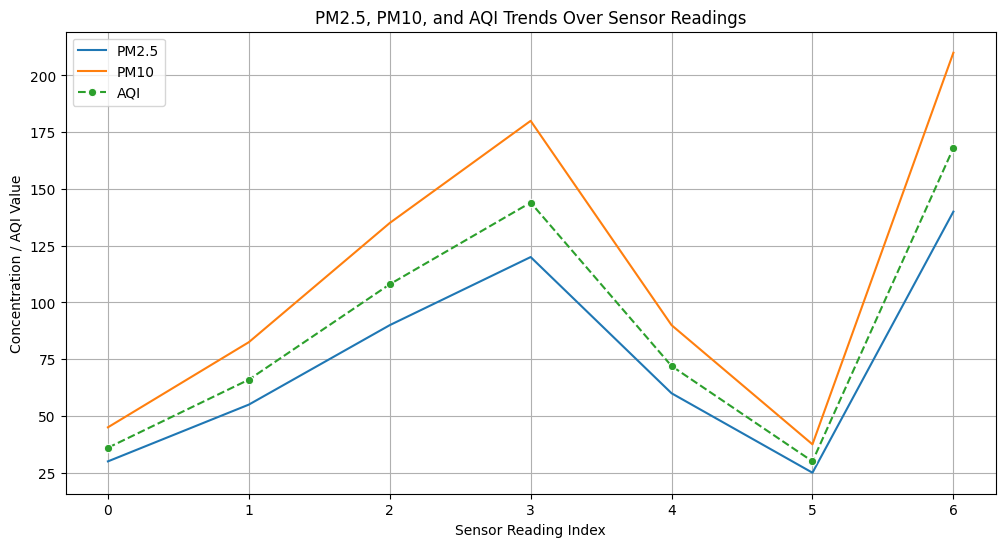

In [ ]:
# Visualizing PM2.5, PM10, and calculated AQI trends
plt.figure(figsize=(12, 6))

sns.lineplot(x=full_sensor_df.index, y='pm25', data=full_sensor_df, label='PM2.5')
sns.lineplot(x=full_sensor_df.index, y='pm10', data=full_sensor_df, label='PM10')
sns.lineplot(x=full_sensor_df.index, y='AQI', data=full_sensor_df, label='AQI', linestyle='--', marker='o')

plt.title('PM2.5, PM10, and AQI Trends Over Sensor Readings')
plt.xlabel('Sensor Reading Index')
plt.ylabel('Concentration / AQI Value')
plt.legend()
plt.grid(True)
plt.show()

### Pollution Level Classification and Health Precautions Theory

Once the AQI is computed, it's mapped to distinct categories that represent varying degrees of health concern. These categories are typically color-coded and assigned descriptive terms (e.g., 'GOOD', 'MODERATE', 'UNHEALTHY', 'DANGER'). Each category comes with specific health advisories and recommended precautions, enabling individuals to mitigate health risks. For instance, 'UNHEALTHY' levels might suggest wearing masks outdoors, while 'DANGER' levels typically advise staying indoors. The `classify` function maps the AQI score to these descriptive statuses, and the `precaution` function provides corresponding health advice.

/tmp/ipykernel_4337/4037943820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=full_sensor_df, order=['GOOD', 'MODERATE', 'UNHEALTHY', 'DANGER'], palette='magma')


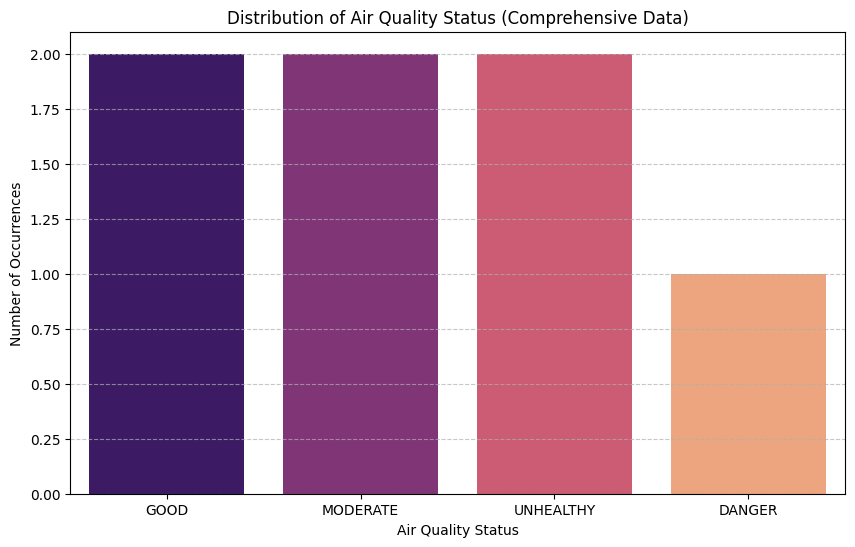

/tmp/ipykernel_4337/4037943820.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Precaution', data=full_sensor_df, order=full_sensor_df['Precaution'].value_counts().index, palette='viridis')


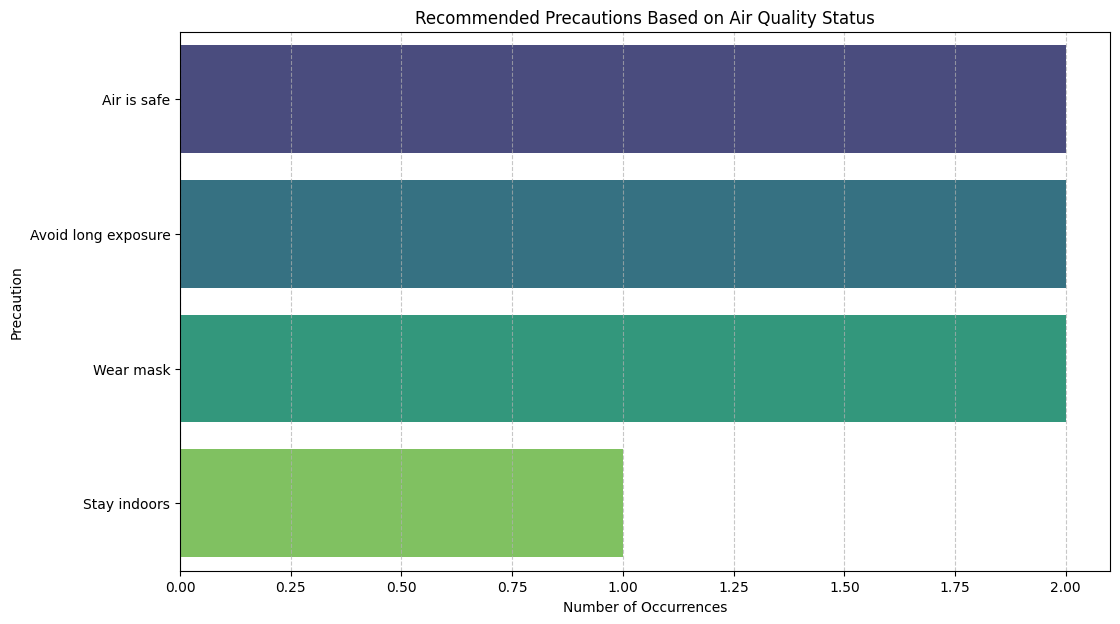

In [ ]:
# Visualizing the distribution of AQI Status from the comprehensive dataset
plt.figure(figsize=(10, 6))
sns.countplot(x='Status', data=full_sensor_df, order=['GOOD', 'MODERATE', 'UNHEALTHY', 'DANGER'], palette='magma')
plt.title('Distribution of Air Quality Status (Comprehensive Data)')
plt.xlabel('Air Quality Status')
plt.ylabel('Number of Occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualizing precautions based on AQI Status
plt.figure(figsize=(12, 7))
sns.countplot(y='Precaution', data=full_sensor_df, order=full_sensor_df['Precaution'].value_counts().index, palette='viridis')
plt.title('Recommended Precautions Based on Air Quality Status')
plt.xlabel('Number of Occurrences')
plt.ylabel('Precaution')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Anomaly Detection Theory with Isolation Forest

Anomaly detection is a crucial aspect of monitoring IoT sensor data, as it helps identify unusual patterns that might indicate sensor malfunctions, environmental hazards, or unexpected events. Isolation Forest is an effective unsupervised machine learning algorithm designed specifically for anomaly detection.

**How Isolation Forest Works:**

Unlike many anomaly detection algorithms that try to define 'normal' behavior, Isolation Forest works on the principle that anomalies are 'few and different' and thus are easier to 'isolate' from normal observations. It achieves this by:

1.  **Random Partitioning:** It randomly selects a feature and then randomly selects a split point between the minimum and maximum values of the selected feature.
2.  **Tree Building:** This partitioning process is recursively repeated to create an 'isolation tree'. The number of splits required to isolate a sample is equivalent to the path length from the root node to the terminating node.
3.  **Anomaly Scoring:** Anomalies are observations that have shorter average path lengths in the isolation trees because they are easier to separate from the rest of the data. Normal observations require more splits to be isolated.

In our context, we apply Isolation Forest to a combination of sensor readings and the calculated AQI to identify data points that deviate significantly from the expected patterns, signaling potential issues with air quality or sensor readings.

In [ ]:
from sklearn.ensemble import IsolationForest

# Initialize and train the Isolation Forest model on relevant features from full_sensor_df
# Features used for anomaly detection can be AQI or a combination of sensor readings
# Using a contamination parameter to estimate the proportion of outliers in the data.
iso_forest = IsolationForest(contamination=0.2, random_state=42) # 0.2 means 20% of the data are considered outliers

# Fit the model and predict anomalies
# The fit_predict method returns -1 for outliers and 1 for inliers (normal points)
full_sensor_df['Anomaly_Score'] = iso_forest.fit_predict(full_sensor_df[['AQI', 'pm25', 'pm10', 'gas_mq135', 'co_mq7']])

# Map the anomaly scores to descriptive labels
full_sensor_df['Anomaly'] = full_sensor_df['Anomaly_Score'].map({1: 'Normal', -1: 'Anomaly'})

print("Comprehensive Sensor Data with Anomaly Detection Results:")
print(full_sensor_df[['AQI', 'pm25', 'pm10', 'gas_mq135', 'co_mq7', 'Anomaly_Score', 'Anomaly']].head(10))

Comprehensive Sensor Data with Anomaly Detection Results:
     AQI  pm25   pm10  gas_mq135  co_mq7  Anomaly_Score  Anomaly
0   36.0    30   45.0        200       5              1   Normal
1   66.0    55   82.5        350       8              1   Normal
2  108.0    90  135.0        500      12              1   Normal
3  144.0   120  180.0        650      15              1   Normal
4   72.0    60   90.0        300       9              1   Normal
5   30.0    25   37.5        150       4             -1  Anomaly
6  168.0   140  210.0        700      18             -1  Anomaly


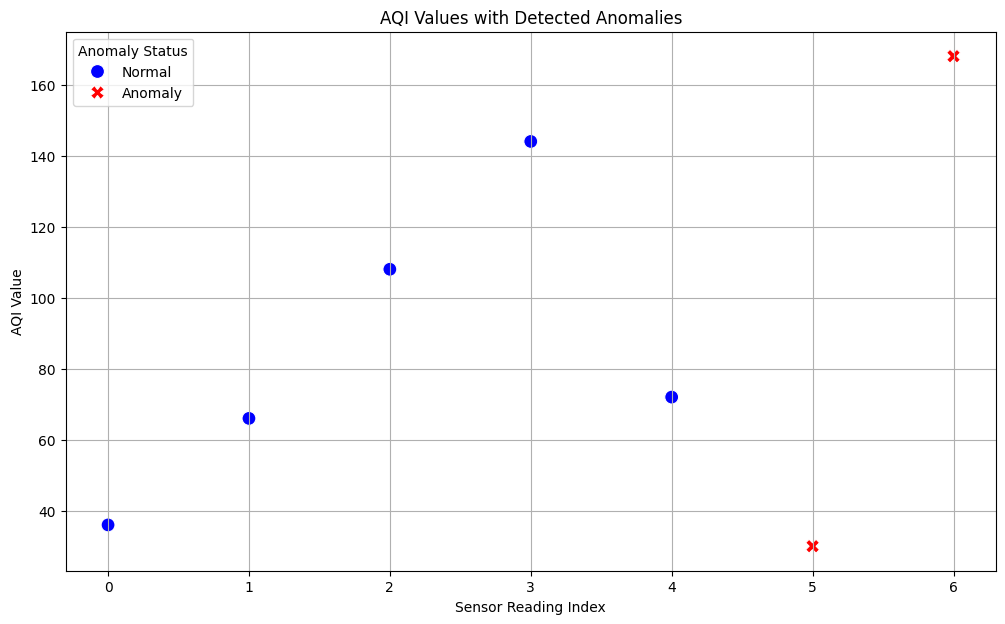

In [ ]:
# Visualizing the anomalies
plt.figure(figsize=(12, 7))
sns.scatterplot(x=full_sensor_df.index, y='AQI', hue='Anomaly', style='Anomaly', data=full_sensor_df, palette={'Normal': 'blue', 'Anomaly': 'red'}, s=100)
plt.title('AQI Values with Detected Anomalies')
plt.xlabel('Sensor Reading Index')
plt.ylabel('AQI Value')
plt.grid(True)
plt.legend(title='Anomaly Status')
plt.show()

### Trend Prediction Theory with Linear Regression

Trend prediction is essential for forecasting future air quality, allowing for proactive measures and warnings. Linear Regression is a fundamental statistical model used to predict a quantitative response based on one or more predictor variables.

**How Linear Regression Works:**

1.  **Objective:** The goal is to establish a linear relationship between a dependent variable (e.g., AQI) and one or more independent variables (e.g., time).
2.  **Model Equation:** The relationship is modeled by fitting a straight line to the observed data. For a single predictor, the equation is typically `Y = b0 + b1*X + e`, where:
    *   `Y` is the dependent variable (AQI).
    *   `X` is the independent variable (time).
    *   `b0` is the Y-intercept (the value of Y when X is 0).
    *   `b1` is the slope of the line (the change in Y for a one-unit change in X).
    *   `e` is the error term, accounting for variability not explained by the model.
3.  **Least Squares Method:** The model determines the `b0` and `b1` coefficients by minimizing the sum of the squared differences between the observed and predicted values (residuals). This method ensures the best-fit line passes through the data points in a way that minimizes the overall prediction error.

In our context, we will use the index of our `full_sensor_df` as a proxy for time (`X`) to predict the Air Quality Index (`AQI`, which is `Y`), helping us to anticipate future air quality trends.

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data for Linear Regression
# Use the DataFrame index as the 'time' variable (X)
X_train = full_sensor_df.index.values.reshape(-1, 1)
# Use AQI as the target variable (y)
y_train = full_sensor_df['AQI'].values

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predict future AQI values (e.g., for the next 3 time steps after the current data)
last_index = full_sensor_df.index.max()
future_indices = np.array([last_index + 1, last_index + 2, last_index + 3]).reshape(-1, 1)
future_aqi_predictions = linear_model.predict(future_indices)

print("Linear Regression Model Coefficients:")
print(f"Intercept: {linear_model.intercept_:.2f}")
print(f"Coefficient: {linear_model.coef_[0]:.2f}")

print("\nFuture AQI Predictions:")
for i, pred in enumerate(future_aqi_predictions):
    print(f"Time Step {future_indices[i][0]}: AQI = {pred:.2f}")

# Add predicted values to the DataFrame for visualization
full_sensor_df['Predicted_AQI'] = linear_model.predict(X_train)

Linear Regression Model Coefficients:
Intercept: 58.29
Coefficient: 10.29

Future AQI Predictions:
Time Step 7: AQI = 130.29
Time Step 8: AQI = 140.57
Time Step 9: AQI = 150.86


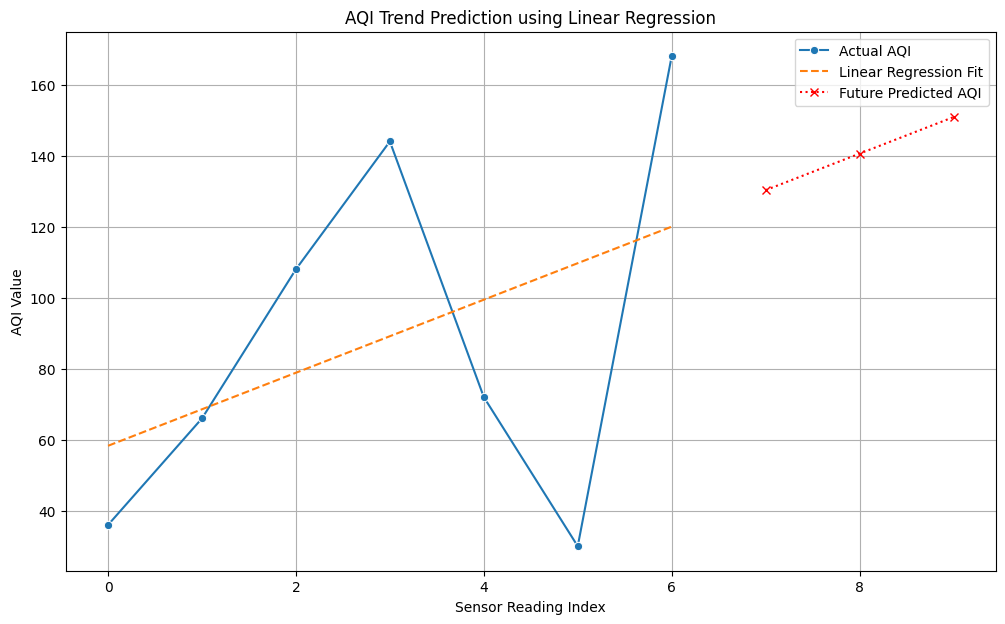

In [ ]:
plt.figure(figsize=(12, 7))

sns.lineplot(x=full_sensor_df.index, y='AQI', data=full_sensor_df, label='Actual AQI', marker='o')
sns.lineplot(x=full_sensor_df.index, y='Predicted_AQI', data=full_sensor_df, label='Linear Regression Fit', linestyle='--')

# Plot future predictions
last_index = full_sensor_df.index.max()
future_indices = np.array([last_index + 1, last_index + 2, last_index + 3])
future_aqi_predictions = linear_model.predict(future_indices.reshape(-1, 1))
plt.plot(future_indices, future_aqi_predictions, marker='x', linestyle=':', color='red', label='Future Predicted AQI')

plt.title('AQI Trend Prediction using Linear Regression')
plt.xlabel('Sensor Reading Index')
plt.ylabel('AQI Value')
plt.grid(True)
plt.legend()
plt.show()

### Risk Classification Theory with Decision Tree Classifier

Risk classification in air quality monitoring is crucial for translating raw sensor data and calculated AQI into actionable health advisories. A **Decision Tree Classifier** is a popular and intuitive machine learning algorithm for this purpose, as it mimics human decision-making processes.

**How a Decision Tree Classifier Works:**

1.  **Tree Structure:** It builds a tree-like model of decisions, where each internal node represents a 'test' on an attribute (e.g., is AQI > 100?), each branch represents the outcome of the test, and each leaf node represents a class label (e.g., 'UNHEALTHY').
2.  **Splitting Criteria:** The algorithm recursively splits the data into subsets based on the feature that provides the best separation between classes. Common splitting criteria include Gini impurity or information gain.
3.  **Prediction:** To classify a new data point, it traverses the tree from the root to a leaf node by evaluating the conditions at each internal node. The class label of the leaf node is assigned as the prediction.

**Why Decision Trees for Risk Classification?**

*   **Interpretability:** Decision trees are easy to understand and interpret, which is vital for explaining health risks to the public.
*   **Handles Mixed Data:** They can naturally handle both numerical and categorical data, which is common in sensor readings and AQI categories.
*   **Non-linear Relationships:** They can capture non-linear relationships between features and the target variable.

In our application, we will use various sensor readings and the calculated AQI as features to predict the air quality `Status` (GOOD, MODERATE, UNHEALTHY, DANGER), thereby classifying the risk associated with the current air quality.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Prepare data for Decision Tree Classifier
# Features: all sensor readings and AQI
X = full_sensor_df[['gas_mq135', 'co_mq7', 'pm25', 'pm10', 'temp', 'humidity', 'motion', 'distance', 'light', 'AQI']]
# Target: Air Quality Status
y = full_sensor_df['Status']

# Encode target variable (Status) into numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
# For this small dataset, we'll train on all data for demonstration,
# but for robust evaluation, a proper train-test split is essential.
# X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

X_train_dt = X
y_train_dt = y_encoded

# Initialize and train the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_dt, y_train_dt)

# Predict the risk levels on the original dataset
full_sensor_df['Predicted_Status_Encoded'] = decision_tree_model.predict(X)
full_sensor_df['Predicted_Status'] = label_encoder.inverse_transform(full_sensor_df['Predicted_Status_Encoded'])

print("Decision Tree Classifier Results (First 10 Rows):")
print(full_sensor_df[['Status', 'Predicted_Status']].head(10))

# Evaluate the model (on the training data for demonstration)
print("\nAccuracy on Training Data:", accuracy_score(y_encoded, full_sensor_df['Predicted_Status_Encoded']))
print("\nClassification Report (Training Data):")
print(classification_report(y_encoded, full_sensor_df['Predicted_Status_Encoded'], target_names=label_encoder.classes_))

Decision Tree Classifier Results (First 10 Rows):
      Status Predicted_Status
0       GOOD             GOOD
1   MODERATE         MODERATE
2  UNHEALTHY        UNHEALTHY
3  UNHEALTHY        UNHEALTHY
4   MODERATE         MODERATE
5       GOOD             GOOD
6     DANGER           DANGER

Accuracy on Training Data: 1.0

Classification Report (Training Data):
              precision    recall  f1-score   support

      DANGER       1.00      1.00      1.00         1
        GOOD       1.00      1.00      1.00         2
    MODERATE       1.00      1.00      1.00         2
   UNHEALTHY       1.00      1.00      1.00         2

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



/tmp/ipykernel_4337/3196178821.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Status', data=full_sensor_df, order=label_encoder.classes_, palette='coolwarm')


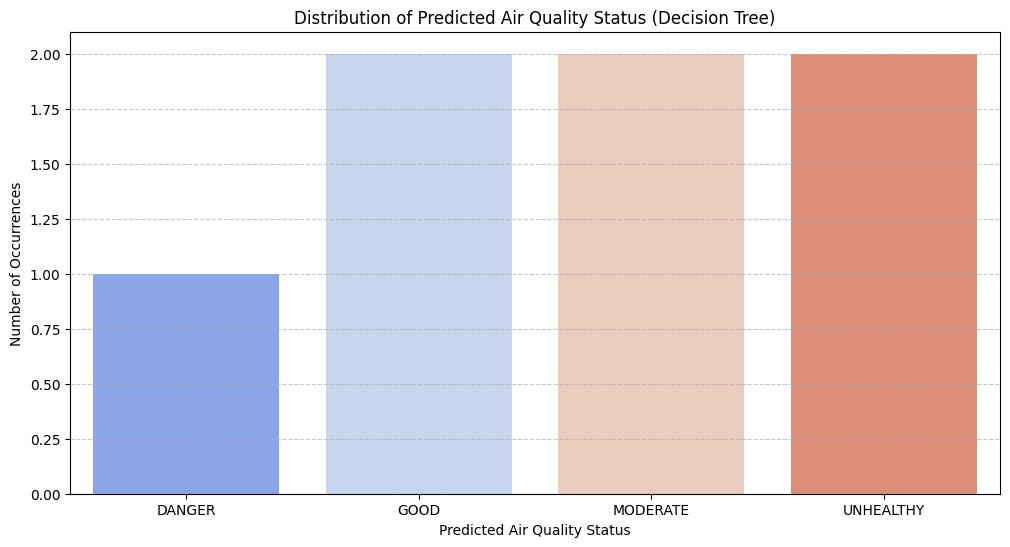

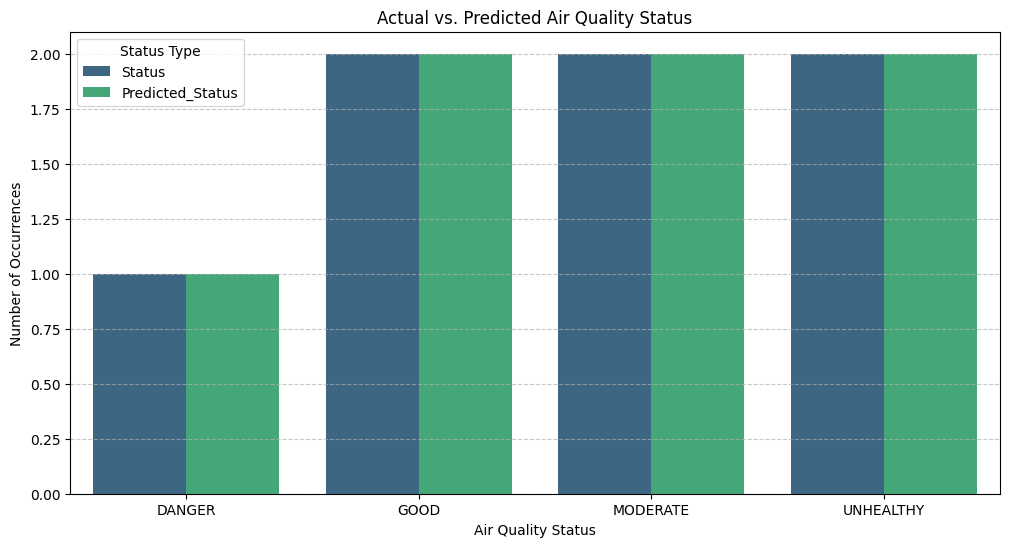

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Predicted_Status', data=full_sensor_df, order=label_encoder.classes_, palette='coolwarm')
plt.title('Distribution of Predicted Air Quality Status (Decision Tree)')
plt.xlabel('Predicted Air Quality Status')
plt.ylabel('Number of Occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# You can also visualize the actual vs. predicted if you had a test set
# For simplicity, here's a comparison of actual vs. predicted on the full dataset (which was used for training)
comparison_df = full_sensor_df[['Status', 'Predicted_Status']].melt(var_name='Type', value_name='Status_Value')
plt.figure(figsize=(12, 6))
sns.countplot(x='Status_Value', hue='Type', data=comparison_df, order=label_encoder.classes_, palette='viridis')
plt.title('Actual vs. Predicted Air Quality Status')
plt.xlabel('Air Quality Status')
plt.ylabel('Number of Occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Status Type')
plt.show()

### Time-of-Day Pattern Analysis (Day/Night Mode) Theory

Understanding how air quality and other environmental parameters fluctuate throughout the day and night can provide crucial insights into pollution sources, human activity patterns, and the effectiveness of mitigation strategies. This 'time-of-day pattern' analysis categorizes sensor readings into 'Day' and 'Night' periods.

**Methodology:**

1.  **Classification:** Data points are classified as 'Day' or 'Night' based on a specific criterion. In the absence of a precise timestamp or sunrise/sunset data, a common approach is to use the `light` sensor readings. For example, a threshold on the `light` sensor can differentiate between periods of high (day) and low (night) ambient light.
2.  **Comparative Analysis:** Once classified, the air quality metrics (like AQI) and other sensor readings can be analyzed separately for 'Day' and 'Night' modes. This helps in identifying distinct patterns, such as:
    *   Higher pollution during the day due to traffic and industrial activity.
    *   Differences in temperature and humidity profiles between day and night.
    *   Variations in gas concentrations.

This analysis helps in developing more targeted and effective environmental monitoring and public health advisories, for instance, by recommending different precautions for day versus night.

In [ ]:
# Classify data into Day/Night based on 'light' sensor
# Assuming a simple threshold: light > 150 is Day, else Night
full_sensor_df['Time_of_Day'] = full_sensor_df['light'].apply(lambda x: 'Day' if x > 150 else 'Night')

print("Sensor Data with Time of Day Classification:")
print(full_sensor_df[['light', 'Time_of_Day', 'AQI']].head(10))

# Analyze AQI patterns for Day vs. Night
day_aqi_mean = full_sensor_df[full_sensor_df['Time_of_Day'] == 'Day']['AQI'].mean()
night_aqi_mean = full_sensor_df[full_sensor_df['Time_of_Day'] == 'Night']['AQI'].mean()

print(f"\nAverage AQI during Day: {day_aqi_mean:.2f}")
print(f"Average AQI during Night: {night_aqi_mean:.2f}")

Sensor Data with Time of Day Classification:
   light Time_of_Day    AQI
0    300         Day   36.0
1    250         Day   66.0
2    200         Day  108.0
3    150       Night  144.0
4    100       Night   72.0
5    350         Day   30.0
6    120       Night  168.0

Average AQI during Day: 60.00
Average AQI during Night: 128.00


/tmp/ipykernel_4337/2886977258.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Time_of_Day', y='AQI', data=full_sensor_df, palette='pastel')


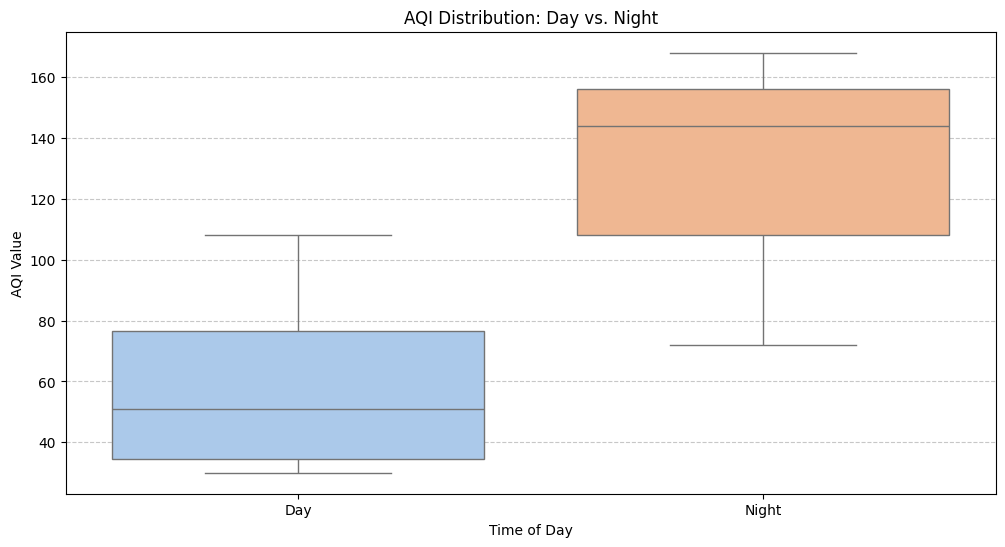

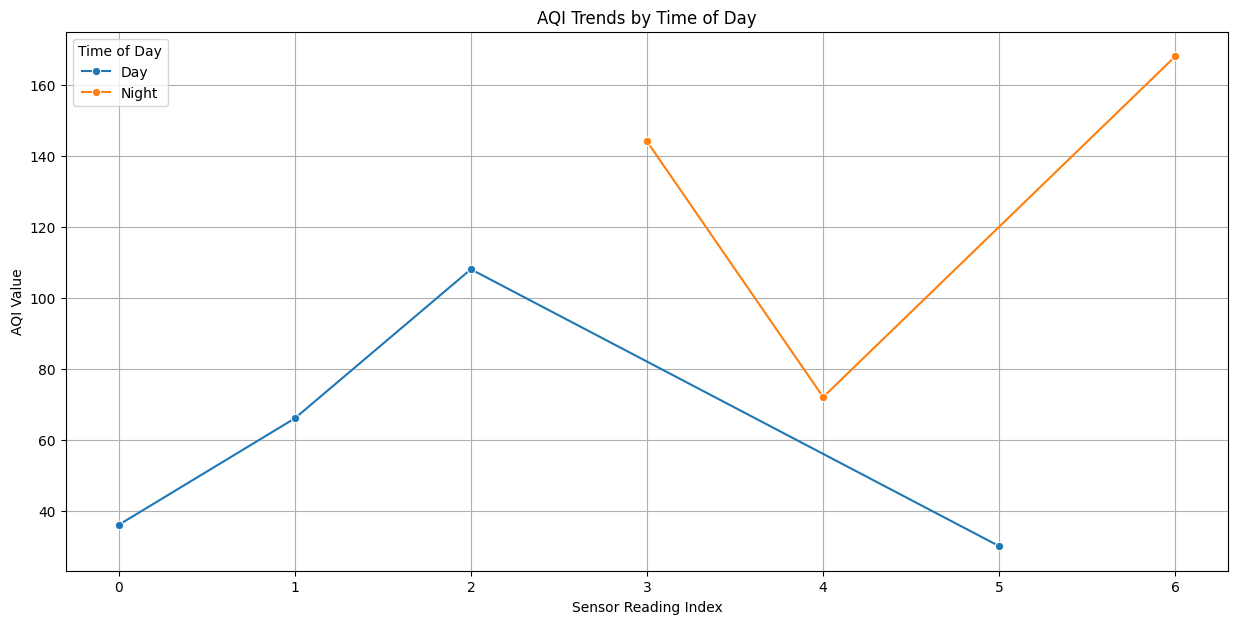

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Time_of_Day', y='AQI', data=full_sensor_df, palette='pastel')
plt.title('AQI Distribution: Day vs. Night')
plt.xlabel('Time of Day')
plt.ylabel('AQI Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# You can extend this to other sensor readings as well
plt.figure(figsize=(15, 7))
sns.lineplot(x=full_sensor_df.index, y='AQI', hue='Time_of_Day', data=full_sensor_df, marker='o')
plt.title('AQI Trends by Time of Day')
plt.xlabel('Sensor Reading Index')
plt.ylabel('AQI Value')
plt.grid(True)
plt.legend(title='Time of Day')
plt.show()

### Health Impact and Cumulative Exposure Theory

Beyond immediate air quality readings, understanding the **cumulative exposure** to pollutants and its potential **health impact** over time is crucial for long-term health monitoring and public health advisories. Cumulative exposure considers not just the momentary pollution level but also the duration and frequency of exposure to various levels of air quality.

**How to Model Cumulative Exposure/Health Impact (Simplified Approach):**

In a real-world scenario, this would involve sophisticated epidemiological models correlating long-term air quality data with health outcomes. However, for a sensor-based system with sequential readings, a simplified approach can be to derive a 'Cumulative Health Risk Index' (CHRI).

1.  **Weighted Averaging:** Instead of just looking at the current AQI, a cumulative index can be calculated using a moving average or an exponentially weighted moving average of past AQI values. This captures the idea that prolonged exposure, even to moderate pollution, can accumulate risk.
2.  **Severity Scoring:** Assigning numerical severity scores to air quality statuses (e.g., GOOD=0, MODERATE=1, UNHEALTHY=2, DANGER=3) allows for a quantifiable cumulative score.
3.  **Risk Categorization:** This continuous cumulative index can then be categorized into discrete risk levels (e.g., 'Low Cumulative Risk', 'Medium Cumulative Risk', 'High Cumulative Risk') to make it actionable.

This derived feature serves as an indicator of potential long-term health risk based on the observed air quality patterns. It can help inform health officials about the need for sustained precautions or interventions.

In [ ]:
# Calculate a Cumulative Health Risk Index (CHRI) based on a rolling average of AQI
# This simulates the effect of prolonged exposure
# Using a window of 3 readings for rolling mean (arbitrary for demonstration on small dataset)
full_sensor_df['Cumulative_Risk_Index'] = full_sensor_df['AQI'].rolling(window=3, min_periods=1).mean()

# Classify Cumulative_Risk_Index into categories for easier interpretation
# Thresholds are exemplary and would be determined by health guidelines in a real scenario
def classify_cumulative_risk(chri):
    if chri <= 60: return "Low Cumulative Risk"
    elif chri <= 120: return "Medium Cumulative Risk"
    else: return "High Cumulative Risk"

full_sensor_df['Cumulative_Risk_Category'] = full_sensor_df['Cumulative_Risk_Index'].apply(classify_cumulative_risk)

print("Sensor Data with Cumulative Health Risk Index and Category (First 10 Rows):")
print(full_sensor_df[['AQI', 'Cumulative_Risk_Index', 'Cumulative_Risk_Category']].head(10))

print(f"\nAverage Cumulative Risk Index: {full_sensor_df['Cumulative_Risk_Index'].mean():.2f}")
print("\nDistribution of Cumulative Risk Categories:")
print(full_sensor_df['Cumulative_Risk_Category'].value_counts())

Sensor Data with Cumulative Health Risk Index and Category (First 10 Rows):
     AQI  Cumulative_Risk_Index Cumulative_Risk_Category
0   36.0                   36.0      Low Cumulative Risk
1   66.0                   51.0      Low Cumulative Risk
2  108.0                   70.0   Medium Cumulative Risk
3  144.0                  106.0   Medium Cumulative Risk
4   72.0                  108.0   Medium Cumulative Risk
5   30.0                   82.0   Medium Cumulative Risk
6  168.0                   90.0   Medium Cumulative Risk

Average Cumulative Risk Index: 77.57

Distribution of Cumulative Risk Categories:
Cumulative_Risk_Category
Medium Cumulative Risk    5
Low Cumulative Risk       2
Name: count, dtype: int64


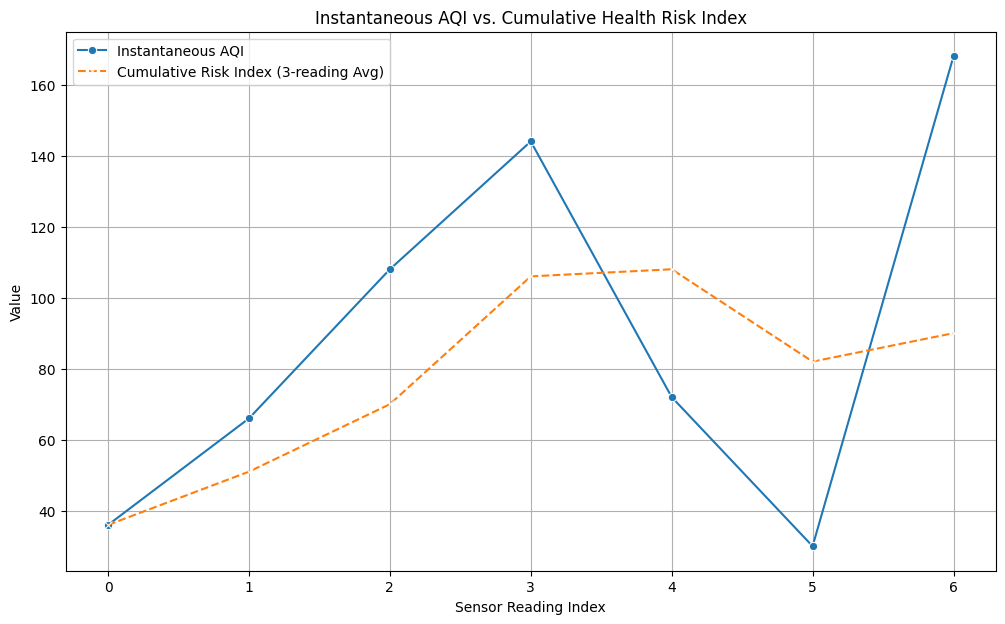

/tmp/ipykernel_4337/327798218.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cumulative_Risk_Category', data=full_sensor_df, palette='coolwarm',


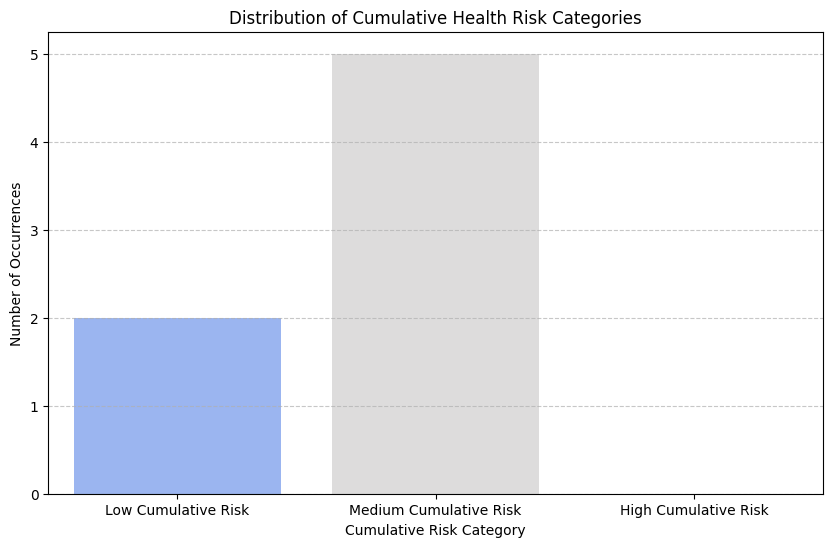

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(x=full_sensor_df.index, y='AQI', data=full_sensor_df, label='Instantaneous AQI', marker='o')
sns.lineplot(x=full_sensor_df.index, y='Cumulative_Risk_Index', data=full_sensor_df, label='Cumulative Risk Index (3-reading Avg)', linestyle='--', marker='x')
plt.title('Instantaneous AQI vs. Cumulative Health Risk Index')
plt.xlabel('Sensor Reading Index')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='Cumulative_Risk_Category', data=full_sensor_df, palette='coolwarm',
              order=['Low Cumulative Risk', 'Medium Cumulative Risk', 'High Cumulative Risk'])
plt.title('Distribution of Cumulative Health Risk Categories')
plt.xlabel('Cumulative Risk Category')
plt.ylabel('Number of Occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Email Alert System Theory

An email alert system is a critical component for an IoT Air Pollution Monitor, enabling proactive notification to users or authorities when air quality levels exceed predefined thresholds or when anomalies are detected. This ensures timely intervention and dissemination of health advisories.

**How Email Alerts Work:**

1.  **Trigger Condition:** The system continuously monitors sensor data and calculated metrics (like AQI, anomaly scores, or risk categories). When a specific condition is met (e.g., AQI enters 'DANGER' status, or an anomaly is detected), an alert is triggered.
2.  **Email Configuration:** The system uses predefined email server settings (SMTP server, port), sender credentials (email address, app password), and recipient email addresses.
3.  **Content Generation:** A descriptive email message is composed, detailing the alert type, current air quality status, relevant sensor readings, and recommended precautions.
4.  **Sending Mechanism:** A Python library (like `smtplib` and `email.mime`) is used to construct and send the email through the configured SMTP server.

For security, it's recommended to use **application-specific passwords** if using services like Gmail, rather than your primary account password. This minimizes risk and is generally a best practice for automated email sending.

In [ ]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

# User configuration for email alerts (already defined in the kernel context)
# ENABLE_EMAIL = False
# EMAIL_SENDER = 'your_email@gmail.com'
# EMAIL_PASSWORD = 'your_app_password' # Use app-specific password for security
# EMAIL_RECEIVER = 'receiver@gmail.com'

def send_email_alert(subject, body, to_email, sender_email, sender_password):
    if not ENABLE_EMAIL:
        print("Email alerts are disabled. Enable 'ENABLE_EMAIL' to send emails.")
        return

    if not sender_email or not sender_password or not to_email:
        print("Email sender, password, or receiver not configured. Skipping email alert.")
        return

    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = to_email
    msg['Subject'] = subject

    msg.attach(MIMEText(body, 'plain'))

    try:
        server = smtplib.SMTP('smtp.gmail.com', 587) # Using Gmail's SMTP server
        server.starttls() # Enable security
        server.login(sender_email, sender_password)
        text = msg.as_string()
        server.sendmail(sender_email, to_email, text)
        server.quit()
        print(f"Email alert sent successfully to {to_email}")
    except Exception as e:
        print(f"Failed to send email alert: {e}")

print("Email alert function defined.")

Email alert function defined.


In [ ]:
# Example: Trigger an email alert if the latest AQI status is 'DANGER'
latest_aqi_status = full_sensor_df['Status'].iloc[-1]
latest_aqi_value = full_sensor_df['AQI'].iloc[-1]
latest_precaution = full_sensor_df['Precaution'].iloc[-1]

if latest_aqi_status == 'DANGER' and ENABLE_EMAIL:
    email_subject = f"CRITICAL AIR QUALITY ALERT - Status: {latest_aqi_status}"
    email_body = (
        f"Dear User,\n\n"
        f"This is an urgent air quality alert from your IoT Air Pollution Monitor.\n"
        f"The latest Air Quality Index (AQI) reading is {latest_aqi_value:.2f}, classified as '{latest_aqi_status}'.\n\n"
        f"Recommended Precaution: {latest_precaution}\n\n"
        f"Please take necessary actions to ensure your safety.\n\n"
        f"Sincerely,\nYour IoT Air Pollution Monitor"
    )
    send_email_alert(email_subject, email_body, EMAIL_RECEIVER, EMAIL_SENDER, EMAIL_PASSWORD)
elif not ENABLE_EMAIL:
    print("Email alert check complete. Email functionality is currently disabled.")
else:
    print(f"Current AQI Status '{latest_aqi_status}' does not trigger an email alert.")

Email alert check complete. Email functionality is currently disabled.


### Telegram Alert System Theory

A Telegram alert system provides a real-time, push-notification-based method to inform users about critical air quality events directly on their mobile devices or desktops. It leverages Telegram's Bot API to send messages programmatically.

**How Telegram Alerts Work:**

1.  **Bot Creation:** First, a Telegram Bot needs to be created using BotFather (a special Telegram bot). This process generates a unique **Bot Token**.
2.  **Chat ID Retrieval:** The bot needs to know where to send messages. This requires obtaining the **Chat ID** of the user or group the bot will send messages to.
3.  **API Interaction:** Python libraries like `requests` are used to interact with Telegram's Bot API. A `POST` request is sent to the API endpoint (`https://api.telegram.org/bot<YOUR_BOT_TOKEN>/sendMessage`) with the `chat_id` and the `text` of the message.
4.  **Trigger Condition:** Similar to email alerts, a specific condition (e.g., AQI 'DANGER' status, anomaly detection) triggers the sending of a Telegram message.

Telegram alerts offer immediate notification, which is crucial for time-sensitive information like severe air quality warnings.

In [ ]:
import requests

# User configuration for Telegram alerts (already defined in the kernel context)
# ENABLE_TELEGRAM = False
# TELEGRAM_TOKEN = 'YOUR_BOT_TOKEN'
# TELEGRAM_CHAT_ID = 'YOUR_CHAT_ID'

def send_telegram_alert(message, bot_token, chat_id):
    if not ENABLE_TELEGRAM:
        print("Telegram alerts are disabled. Enable 'ENABLE_TELEGRAM' to send messages.")
        return

    if not bot_token or not chat_id:
        print("Telegram bot token or chat ID not configured. Skipping Telegram alert.")
        return

    url = f"https://api.telegram.org/bot{bot_token}/sendMessage"
    payload = {
        'chat_id': chat_id,
        'text': message
    }
    try:
        response = requests.post(url, data=payload)
        response.raise_for_status() # Raise an exception for bad status codes
        print(f"Telegram alert sent successfully to chat ID {chat_id}")
    except requests.exceptions.RequestException as e:
        print(f"Failed to send Telegram alert: {e}")

print("Telegram alert function defined.")

Telegram alert function defined.


In [ ]:
# Example: Trigger a Telegram alert if the latest AQI status is 'DANGER'
latest_aqi_status = full_sensor_df['Status'].iloc[-1]
latest_aqi_value = full_sensor_df['AQI'].iloc[-1]
latest_precaution = full_sensor_df['Precaution'].iloc[-1]

if latest_aqi_status == 'DANGER' and ENABLE_TELEGRAM:
    telegram_message = (
        f"*CRITICAL AIR QUALITY ALERT!*\n\n"
        f"The latest Air Quality Index (AQI) reading is `{latest_aqi_value:.2f}`, classified as '{latest_aqi_status}'.\n\n"
        f"*Recommended Precaution:* {latest_precaution}\n\n"
        f"Please take necessary actions to ensure your safety."
    )
    send_telegram_alert(telegram_message, TELEGRAM_TOKEN, TELEGRAM_CHAT_ID)
elif not ENABLE_TELEGRAM:
    print("Telegram alert check complete. Telegram functionality is currently disabled.")
else:
    print(f"Current AQI Status '{latest_aqi_status}' does not trigger a Telegram alert.")

Telegram alert check complete. Telegram functionality is currently disabled.


### Voice Alert System Theory (Text-to-Speech)

A voice alert system provides an auditory notification for critical air quality events, which can be particularly useful for immediate, hands-free awareness in various environments. This system converts textual alert messages into spoken words using Text-to-Speech (TTS) technology.

**How Voice Alerts Work:**

1.  **Text Generation:** An alert message is composed based on trigger conditions (e.g., AQI status, anomaly detection), similar to email or Telegram alerts.
2.  **TTS Engine:** A Text-to-Speech engine (like `gTTS` for Google Text-to-Speech or `pyttsx3` for offline capabilities) takes the text message as input.
3.  **Audio Output:** The TTS engine converts the text into an audio file (e.g., MP3) or directly plays it through the system's speakers.
4.  **Trigger Condition:** The voice alert is activated when specific thresholds are met, delivering a spoken warning to users.

For practical deployment, especially on devices like the ESP32, integrating an external TTS service or using a lightweight embedded TTS library would be necessary. For demonstration purposes in a Python environment, `gTTS` (which requires an internet connection) or `pyttsx3` (which uses installed TTS voices) are common choices. Here, we'll use `gTTS` for simplicity, assuming an internet connection.

In [ ]:
!pip install gTTS
from gtts import gTTS
import os

# User configuration for voice alerts (already defined in the kernel context)
# ENABLE_VOICE = False

def send_voice_alert(message, filename="voice_alert.mp3"):
    if not ENABLE_VOICE:
        print("Voice alerts are disabled. Enable 'ENABLE_VOICE' to generate voice alerts.")
        return

    print(f"Generating voice alert: {message}")
    try:
        tts = gTTS(text=message, lang='en')
        tts.save(filename)
        print(f"Voice alert saved as '{filename}'. You can play it using an audio player.")
        # In a real-time system, you would play this file directly:
        # os.system(f"mpg321 {filename}") # Example for Linux
        # For Colab, playing directly might require specific setup or just downloading.
    except Exception as e:
        print(f"Failed to generate voice alert: {e}")

print("Voice alert function defined.")

Voice alert function defined.


In [ ]:
# Example: Trigger a voice alert if the latest AQI status is 'DANGER'
latest_aqi_status = full_sensor_df['Status'].iloc[-1]
latest_aqi_value = full_sensor_df['AQI'].iloc[-1]
latest_precaution = full_sensor_df['Precaution'].iloc[-1]

if latest_aqi_status == 'DANGER' and ENABLE_VOICE:
    voice_message = (
        f"Critical Air Quality Alert! "
        f"The latest Air Quality Index is {latest_aqi_value:.0f}, classified as {latest_aqi_status}. "
        f"Recommended Precaution: {latest_precaution}. "
        f"Please take necessary actions for your safety."
    )
    send_voice_alert(voice_message)
elif not ENABLE_VOICE:
    print("Voice alert check complete. Voice functionality is currently disabled.")
else:
    print(f"Current AQI Status '{latest_aqi_status}' does not trigger a voice alert.")

Voice alert check complete. Voice functionality is currently disabled.


### Report Generation Theory (CSV & PDF)

Reporting is a crucial aspect of any monitoring system, as it provides a structured way to summarize and present collected data and analysis results. For an IoT Air Pollution Monitor, reports can serve various purposes:

1.  **Historical Record:** Documenting air quality trends over time for compliance, research, or retrospective analysis.
2.  **Stakeholder Communication:** Providing easily digestible information to users, environmental agencies, or city planners.
3.  **Actionable Insights:** Highlighting critical events, cumulative risks, or anomaly detections that require intervention.

**CSV (Comma Separated Values) Reports:**

CSV files are a simple and widely supported format for tabular data. They are excellent for:
*   **Data Export:** Easily exporting raw or processed sensor data for further analysis in spreadsheets or other data tools.
*   **Machine Readability:** Their plain text nature makes them easy for other programs to parse and integrate.

**PDF (Portable Document Format) Reports:**

PDFs are ideal for generating static, visually consistent documents that are independent of the software or hardware used to view them. They are preferred for:
*   **Formal Documentation:** Creating professional-looking summaries, certificates, or compliance reports.
*   **Readability & Printing:** Ensuring that reports retain their formatting when viewed on different devices or printed.

In this section, we will generate both a CSV file containing the raw AQI data and a simple PDF report that lists these AQI values, demonstrating how to create shareable and printable outputs from our air quality monitoring system.

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

st.set_page_config(layout="wide", page_title="IoT Air Pollution Monitor")

# --- 1. AQI Calculation and Classification Functions ---
def calculate_aqi(pm25, pm10):
    return (0.6 * pm25) + (0.4 * pm10)

def classify(aqi):
    if aqi <= 50: return "GOOD"
    elif aqi <= 100: return "MODERATE"
    elif aqi <= 150: return "UNHEALTHY"
    else: return "DANGER"

def precaution(level):
    if level == "GOOD": return "Air is safe"
    elif level == "MODERATE": return "Avoid long exposure"
    elif level == "UNHEALTHY": return "Wear mask"
    else: return "Stay indoors"

def classify_cumulative_risk(chri):
    if chri <= 60: return "Low Cumulative Risk"
    elif chri <= 120: return "Medium Cumulative Risk"
    else: return "High Cumulative Risk"

# --- 2. Data Simulation (re-creating full_sensor_df) ---
data = {'gas_mq135': [200, 350, 500, 650, 300, 150, 700],
        'co_mq7': [5, 8, 12, 15, 9, 4, 18],
        'pm25': [30, 55, 90, 120, 60, 25, 140],
        'temp': [25, 27, 30, 32, 28, 26, 33],
        'humidity': [60, 65, 70, 75, 68, 62, 78],
        'motion': [0, 1, 1, 0, 1, 0, 1],
        'distance': [100, 80, 60, 40, 70, 120, 30],
        'light': [300, 250, 200, 150, 100, 350, 120]}

full_sensor_df = pd.DataFrame(data)
full_sensor_df['pm10'] = full_sensor_df['pm25'] * 1.5

# Apply AQI, Status, Precaution
full_sensor_df['AQI'] = full_sensor_df.apply(lambda x: calculate_aqi(x['pm25'], x['pm10']), axis=1)
full_sensor_df['Status'] = full_sensor_df['AQI'].apply(classify)
full_sensor_df['Precaution'] = full_sensor_df['Status'].apply(precaution)

# --- 3. Anomaly Detection ---
iso_forest = IsolationForest(contamination=0.2, random_state=42)
full_sensor_df['Anomaly_Score'] = iso_forest.fit_predict(full_sensor_df[['AQI', 'pm25', 'pm10', 'gas_mq135', 'co_mq7']])
full_sensor_df['Anomaly'] = full_sensor_df['Anomaly_Score'].map({1: 'Normal', -1: 'Anomaly'})

# --- 4. Trend Prediction ---
X_train = full_sensor_df.index.values.reshape(-1, 1)
y_train = full_sensor_df['AQI'].values
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
full_sensor_df['Predicted_AQI'] = linear_model.predict(X_train)

# Predict future AQI values
last_index = full_sensor_df.index.max()
future_indices = np.array([last_index + 1, last_index + 2, last_index + 3]).reshape(-1, 1)
future_aqi_predictions = linear_model.predict(future_indices)
future_predictions_df = pd.DataFrame({
    'index': future_indices.flatten(),
    'AQI': future_aqi_predictions,
    'Type': 'Future Predicted'
})

# --- 5. Risk Classification ---
X_dt = full_sensor_df[['gas_mq135', 'co_mq7', 'pm25', 'pm10', 'temp', 'humidity', 'motion', 'distance', 'light', 'AQI']]
y_dt = full_sensor_df['Status']
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_dt)
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_dt, y_encoded)
full_sensor_df['Predicted_Status_Encoded'] = decision_tree_model.predict(X_dt)
full_sensor_df['Predicted_Status'] = label_encoder.inverse_transform(full_sensor_df['Predicted_Status_Encoded'])

# --- 6. Time-of-Day Pattern Analysis ---
full_sensor_df['Time_of_Day'] = full_sensor_df['light'].apply(lambda x: 'Day' if x > 150 else 'Night')

# --- 7. Cumulative Exposure ---
full_sensor_df['Cumulative_Risk_Index'] = full_sensor_df['AQI'].rolling(window=3, min_periods=1).mean()
full_sensor_df['Cumulative_Risk_Category'] = full_sensor_df['Cumulative_Risk_Index'].apply(classify_cumulative_risk)

# --- Streamlit Dashboard Layout ---
st.title("\U0001F30D IoT Air Pollution Monitor Dashboard")

# --- Sidebar for Latest Readings and Status ---
st.sidebar.header("Latest Readings")
latest_data = full_sensor_df.iloc[-1]
st.sidebar.metric(label="Latest AQI", value=f"{latest_data['AQI']:.2f}")
st.sidebar.markdown(f"**Status:** <span style='color: {'green' if latest_data['Status'] == 'GOOD' else 'orange' if latest_data['Status'] == 'MODERATE' else 'red' if latest_data['Status'] == 'UNHEALTHY' else 'darkred'};'>**{latest_data['Status']}**</span>", unsafe_allow_html=True)
st.sidebar.info(f"**Precaution:** {latest_data['Precaution']}")
st.sidebar.write(f"**Anomaly Status:** {latest_data['Anomaly']}")
st.sidebar.write(f"**Cumulative Risk:** {latest_data['Cumulative_Risk_Category']}")

st.sidebar.markdown("--- ")
st.sidebar.header("Sensor Details")
for col in ['gas_mq135', 'co_mq7', 'pm25', 'pm10', 'temp', 'humidity', 'motion', 'distance', 'light']:
    st.sidebar.write(f"{col.replace('_', ' ').title()}: {latest_data[col]}")

# --- Main Content ---

st.subheader("Real-time Air Quality Trends")

col1, col2 = st.columns(2)

with col1:
    st.markdown("##### PM2.5, PM10 and AQI Trends")
    fig1, ax1 = plt.subplots(figsize=(10, 5))
    sns.lineplot(x=full_sensor_df.index, y='pm25', data=full_sensor_df, label='PM2.5', ax=ax1)
    sns.lineplot(x=full_sensor_df.index, y='pm10', data=full_sensor_df, label='PM10', ax=ax1)
    sns.lineplot(x=full_sensor_df.index, y='AQI', data=full_sensor_df, label='AQI', linestyle='--', marker='o', ax=ax1)
    ax1.set_title('PM2.5, PM10, and AQI Trends Over Sensor Readings')
    ax1.set_xlabel('Sensor Reading Index')
    ax1.set_ylabel('Concentration / AQI Value')
    ax1.grid(True)
    st.pyplot(fig1)

with col2:
    st.markdown("##### AQI Trend Prediction")
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    sns.lineplot(x=full_sensor_df.index, y='AQI', data=full_sensor_df, label='Actual AQI', marker='o', ax=ax2)
    sns.lineplot(x=full_sensor_df.index, y='Predicted_AQI', data=full_sensor_df, label='Linear Regression Fit', linestyle='--', ax=ax2)
    plt.plot(future_predictions_df['index'], future_predictions_df['AQI'], marker='x', linestyle=':', color='red', label='Future Predicted AQI', ax=ax2)
    ax2.set_title('AQI Trend Prediction using Linear Regression')
    ax2.set_xlabel('Sensor Reading Index')
    ax2.set_ylabel('AQI Value')
    ax2.grid(True)
    st.pyplot(fig2)

st.markdown("--- ")

st.subheader("Air Quality Status & Anomaly Detection")

col3, col4 = st.columns(2)

with col3:
    st.markdown("##### Distribution of Air Quality Status")
    fig3, ax3 = plt.subplots(figsize=(10, 5))
    sns.countplot(x='Status', data=full_sensor_df, order=['GOOD', 'MODERATE', 'UNHEALTHY', 'DANGER'], palette='magma', ax=ax3)
    ax3.set_title('Distribution of Air Quality Status')
    ax3.set_xlabel('Air Quality Status')
    ax3.set_ylabel('Number of Occurrences')
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    st.pyplot(fig3)

with col4:
    st.markdown("##### AQI Values with Detected Anomalies")
    fig4, ax4 = plt.subplots(figsize=(10, 5))
    sns.scatterplot(x=full_sensor_df.index, y='AQI', hue='Anomaly', style='Anomaly', data=full_sensor_df, palette={'Normal': 'blue', 'Anomaly': 'red'}, s=100, ax=ax4)
    ax4.set_title('AQI Values with Detected Anomalies')
    ax4.set_xlabel('Sensor Reading Index')
    ax4.set_ylabel('AQI Value')
    ax4.grid(True)
    ax4.legend(title='Anomaly Status')
    st.pyplot(fig4)

st.markdown("--- ")

st.subheader("Health Impact & Time-based Analysis")

col5, col6 = st.columns(2)

with col5:
    st.markdown("##### Cumulative Health Risk Index")
    fig5, ax5 = plt.subplots(figsize=(10, 5))
    sns.lineplot(x=full_sensor_df.index, y='AQI', data=full_sensor_df, label='Instantaneous AQI', marker='o', ax=ax5)
    sns.lineplot(x=full_sensor_df.index, y='Cumulative_Risk_Index', data=full_sensor_df, label='Cumulative Risk Index (3-reading Avg)', linestyle='--', marker='x', ax=ax5)
    ax5.set_title('Instantaneous AQI vs. Cumulative Health Risk Index')
    ax5.set_xlabel('Sensor Reading Index')
    ax5.set_ylabel('Value')
    ax5.grid(True)
    st.pyplot(fig5)

with col6:
    st.markdown("##### AQI Distribution: Day vs. Night")
    fig6, ax6 = plt.subplots(figsize=(10, 5))
    sns.boxplot(x='Time_of_Day', y='AQI', data=full_sensor_df, palette='pastel', ax=ax6)
    ax6.set_title('AQI Distribution: Day vs. Night')
    ax6.set_xlabel('Time of Day')
    ax6.set_ylabel('AQI Value')
    ax6.grid(axis='y', linestyle='--', alpha=0.7)
    st.pyplot(fig6)

st.markdown("--- ")

st.subheader("Raw Data Table")
st.dataframe(full_sensor_df)

# --- Alert System Placeholders (for demonstration of trigger conditions) ---
st.markdown("### Alert System Status (Backend Triggers)")

latest_aqi_status = full_sensor_df['Status'].iloc[-1]
latest_aqi_value = full_sensor_df['AQI'].iloc[-1]
latest_precaution = full_sensor_df['Precaution'].iloc[-1]

if latest_aqi_status == 'DANGER':
    st.error(f"\U000026A0 CRITICAL ALERT: Current AQI is DANGER ({latest_aqi_value:.2f}). Precaution: {latest_precaution}.")
    st.write("\U0001F4E7 Email alert would be triggered (if enabled and configured).")
    st.write("\U0001F4AC Telegram alert would be triggered (if enabled and configured).")
    st.write("\U0001F50A Voice alert would be generated (if enabled and configured).")
elif full_sensor_df['Anomaly'].iloc[-1] == 'Anomaly':
    st.warning("\U000026A0 ANOMALY DETECTED: An unusual reading pattern has been identified.")
    st.write("Anomaly alerts would be triggered (if configured).")
else:
    st.success("Current air quality conditions are normal and stable.")


Overwriting app.py


To run this Streamlit application:

1.  **Save the file**: The `%%writefile app.py` command above saves the code to a file named `app.py` in your current directory.
2.  **Open a terminal**: In Google Colab, go to `Runtime > Open runtime in Colab` or find the `Terminal` icon on the left sidebar.
3.  **Navigate to the directory**: If you're not already in `/content/`, you might need to change to it: `cd /content/`
4.  **Install Streamlit (if not already installed)**: `pip install streamlit`
5.  **Run the app**: `streamlit run app.py`

Streamlit will then provide you with a local URL to view your dashboard, usually starting with `http://localhost:8501`. Since you're in Colab, it will likely give you a public URL (like `https://<random-hash>-8501.colab.googleusercontent.com/`) that you can click to open the dashboard in your browser.

### Visualization of Reported AQI Data

To provide a visual context for the data included in the report, we can plot the AQI values. This helps in quickly understanding the distribution and trend of the air quality readings that were summarized in the generated files.

In [ ]:
# Install fpdf library
%pip install fpdf

In [ ]:
import pandas as pd
from fpdf import FPDF

df = pd.DataFrame({'AQI':[40,80,120]})

df.to_csv("corrected_report.csv")
print("Corrected AQI data saved to corrected_report.csv")

pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", size=12)

for i in df['AQI']:
    pdf.cell(200,10,txt=str(i),ln=True) # Corrected: Added txt= argument

pdf.output("corrected_report.pdf")
print("Corrected PDF report saved to corrected_report.pdf")

Corrected AQI data saved to corrected_report.csv
Corrected PDF report saved to corrected_report.pdf


/tmp/ipykernel_4337/100915383.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_report.index, y='AQI', data=df_report, palette='coolwarm')


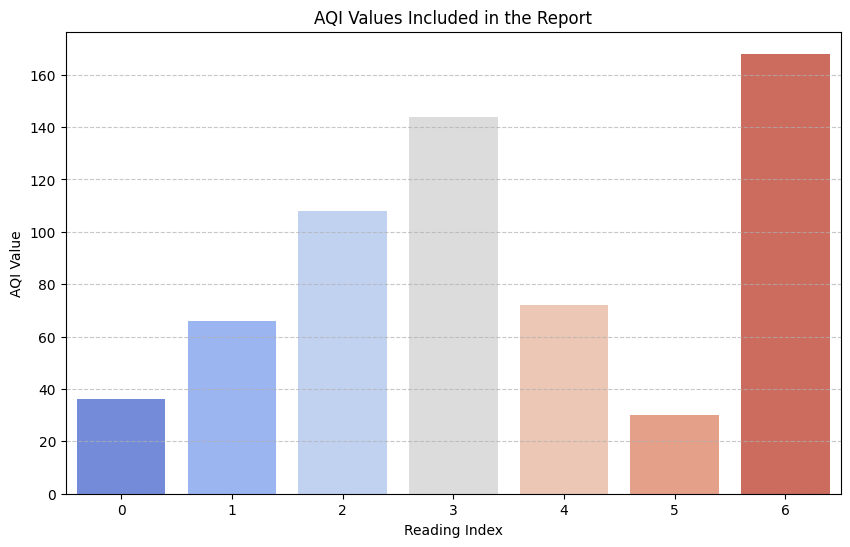

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Redefine df_report using the comprehensive full_sensor_df for visualization
df_report = pd.DataFrame({'AQI': full_sensor_df['AQI']})

plt.figure(figsize=(10, 6))
sns.barplot(x=df_report.index, y='AQI', data=df_report, palette='coolwarm')
plt.title('AQI Values Included in the Report')
plt.xlabel('Reading Index')
plt.ylabel('AQI Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

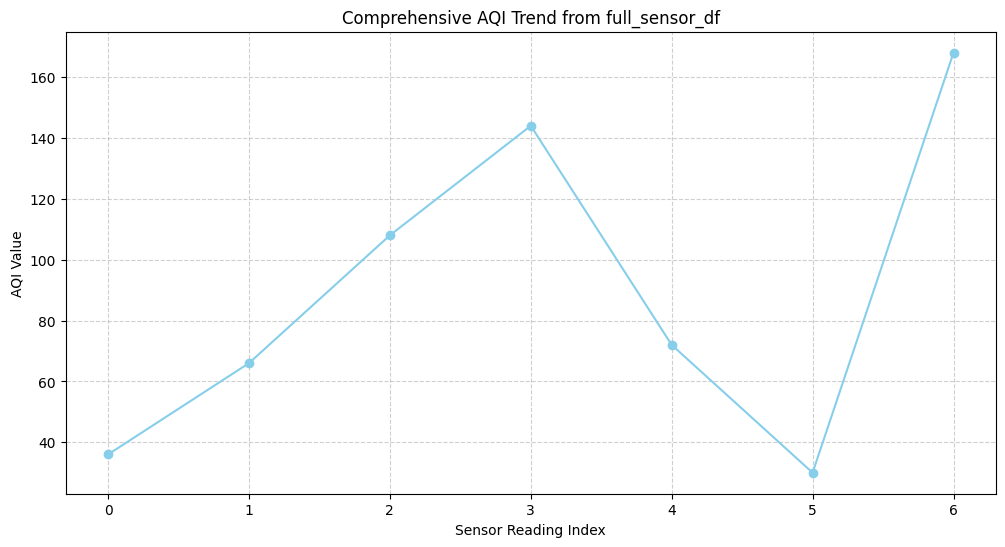

In [ ]:
import matplotlib.pyplot as plt

# Using AQI data from the comprehensive full_sensor_df
aqi_data = full_sensor_df['AQI']

plt.figure(figsize=(12, 6))
plt.plot(aqi_data, marker='o', linestyle='-', color='skyblue')
plt.title('Comprehensive AQI Trend from full_sensor_df')
plt.xlabel('Sensor Reading Index')
plt.ylabel('AQI Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()